In [1]:
%pip install -e ..

Obtaining file:///Users/pratikeliasjacob/Documents/Projects/simple-transformer
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for simple-transformer (pyproject.toml) ... done
  Created wheel for simple-transformer: filename=simple_transformer-0.1.0-0.editable-py3-none-any.whl size=2129 sha256=ce90bd48bb1fa4d88f99ae15807961c86dd276751c4007e9a48c10dcb9640e8a
  Stored in directory: /private/var/folders/qn/79klx_zs0m1fqrh1q4c5ql_00000gn/T/pip-ephem-wheel-cache-wn3fcnty/wheels/de/d4/87/c813e0cb6465938cfd1c4350e8aa954bcfb9b50edc775763b4
Successfully built simple-transformer
  Attempting uninstall: simple-transformer
    Found existing installation: simple-transformer 0.1.0
    Uninstalling simple-transformer-0.1.0:
      Successfully uninstalled simple-transformer-0.1.0
Note: you may need to restart the kernel to 

In [2]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from simple_transformer.config import local_training_config, small_model_config
from simple_transformer.data import make_addition_dataloader
from simple_transformer.metrics import TensorBoardTrainingObserver
from simple_transformer.model import SimpleTransformerLM, count_parameters
from simple_transformer.train import fit, make_train_val_loaders


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.0
cpu


In [4]:
custom_examples = [
    "1+2=",
    "7+8=",
    "12+3=",
    "45+54=",
    "99+1=",
    "20+30=",
    "88+11=",
    "10+5=",
    "0+0=",
    "99+99=",
    "5+0=",
    "0+9=",
    "10+0=",
]

for example in custom_examples:
    print(example)

1+2=
7+8=
12+3=
45+54=
99+1=
20+30=
88+11=
10+5=
0+0=
99+99=
5+0=
0+9=
10+0=


In [5]:
loader, tokenizer = make_addition_dataloader(
    num_examples=8,
    max_digits=2,
    batch_size=4,
    seed=42,
    shuffle=False,
)

batch = next(iter(loader))
print(batch["input_ids"].shape, batch["labels"].shape)
print(tokenizer.decode(batch["input_ids"][0]))

torch.Size([4, 9]) torch.Size([4, 9])
81+14=95


In [6]:
def show_generations(model, tokenizer, examples):
    model.eval()
    prompt_ids = [tokenizer.encode(example) for example in examples]
    generated_ids = model.generate_batch(
        prompt_ids,
        eos_token_id=tokenizer.eos_token_id,
    )

    for prompt, output_ids in zip(examples, generated_ids):
        print(f"{prompt:>8} -> {tokenizer.decode(output_ids)}")

In [7]:
train_config = local_training_config(max_digits=2, device=device)

model_config = small_model_config(
    max_digits=train_config.max_digits,
    device=train_config.device,
)
model = SimpleTransformerLM(model_config)
train_loader, val_loader, tokenizer = make_train_val_loaders(train_config)
run_dir = Path("..") / "runs" / datetime.now().strftime("addition-%Y%m%d-%H%M%S")
observer = TensorBoardTrainingObserver(run_dir)
observer.log_config(
    training_config=train_config,
    model_config=model_config,
    parameter_count=count_parameters(model),
)

print(f"parameters: {count_parameters(model):,}")
print(f"force flash: {model_config.force_flash}")
print(f"train batches: {len(train_loader)}, validation batches: {len(val_loader)}")
print(f"TensorBoard log dir: {run_dir}")
print("Terminal: tensorboard --logdir runs")
print("Before training:")
show_generations(model, tokenizer, custom_examples)


parameters: 2,032,320
force flash: False
train batches: 256, validation batches: 8
TensorBoard log dir: ../runs/addition-20260619-163900
Terminal: tensorboard --logdir runs
Before training:
    1+2= -> 1+2=======
    7+8= -> 7+8=======
   12+3= -> 12+3======
  45+54= -> 45+54=====
   99+1= -> 99+1======
  20+30= -> 20+30=====
  88+11= -> 88+11=====
   10+5= -> 10+5======
    0+0= -> 0+0=888888
  99+99= -> 99+99=====
    5+0= -> 5+0===6666
    0+9= -> 0+9=======
   10+0= -> 10+0======


In [8]:
def print_epoch(epoch, train, validation):
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train.loss:.4f} acc {train.accuracy:.3f} | "
        f"val loss {validation.loss:.4f} acc {validation.accuracy:.3f} | "
        f"lr {train.learning_rate:.2e}"
    )

try:
    history = fit(
        model,
        train_loader,
        val_loader,
        train_config,
        on_epoch=print_epoch,
        observer=observer,
    )
finally:
    observer.close()


epoch 01 | train loss 1.3139 acc 0.527 | val loss 0.9401 acc 0.654 | lr 3.00e-04
epoch 02 | train loss 0.5706 acc 0.777 | val loss 0.4364 acc 0.823 | lr 2.98e-04
epoch 03 | train loss 0.3182 acc 0.877 | val loss 0.3448 acc 0.853 | lr 2.96e-04
epoch 04 | train loss 0.2137 acc 0.920 | val loss 0.2891 acc 0.882 | lr 2.94e-04
epoch 05 | train loss 0.1746 acc 0.936 | val loss 0.1296 acc 0.955 | lr 2.90e-04
epoch 06 | train loss 0.1380 acc 0.949 | val loss 0.0592 acc 0.983 | lr 2.85e-04
epoch 07 | train loss 0.1112 acc 0.960 | val loss 0.0733 acc 0.973 | lr 2.80e-04
epoch 08 | train loss 0.0890 acc 0.968 | val loss 0.0564 acc 0.980 | lr 2.74e-04
epoch 09 | train loss 0.0749 acc 0.974 | val loss 0.0615 acc 0.971 | lr 2.68e-04
epoch 10 | train loss 0.0643 acc 0.978 | val loss 0.0286 acc 0.992 | lr 2.61e-04
epoch 11 | train loss 0.0530 acc 0.982 | val loss 0.0176 acc 0.995 | lr 2.53e-04
epoch 12 | train loss 0.0392 acc 0.986 | val loss 0.0507 acc 0.981 | lr 2.45e-04
epoch 13 | train loss 0.0315

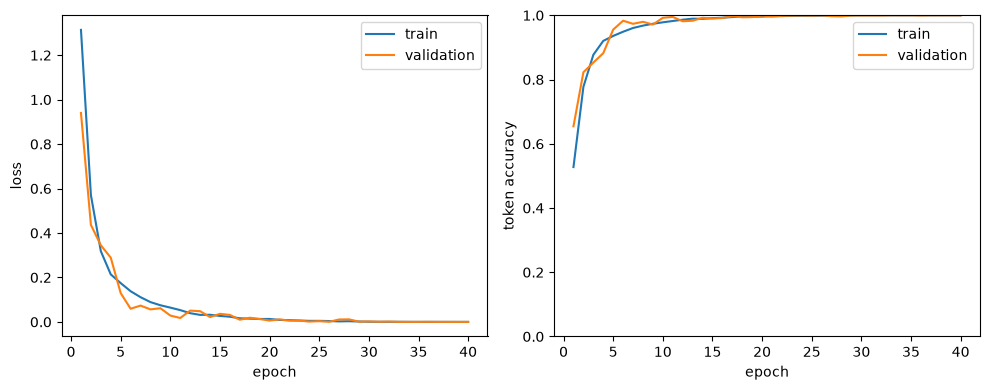

In [9]:
epochs = range(1, len(history.train) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [metrics.loss for metrics in history.train], label="train")
plt.plot(epochs, [metrics.loss for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [metrics.accuracy for metrics in history.train], label="train")
plt.plot(epochs, [metrics.accuracy for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("token accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

In [10]:
print("After training:")
show_generations(model, tokenizer, custom_examples)

final_train = history.train[-1]
final_validation = history.validation[-1]
print(
    f"final train loss={final_train.loss:.4f}, "
    f"train acc={final_train.accuracy:.3f}, "
    f"val loss={final_validation.loss:.4f}, "
    f"val acc={final_validation.accuracy:.3f}"
)

After training:
    1+2= -> 1+2=3
    7+8= -> 7+8=15
   12+3= -> 12+3=15
  45+54= -> 45+54=99
   99+1= -> 99+1=100
  20+30= -> 20+30=50
  88+11= -> 88+11=99
   10+5= -> 10+5=15
    0+0= -> 0+0=0
  99+99= -> 99+99=198
    5+0= -> 5+0=5
    0+9= -> 0+9=9
   10+0= -> 10+0=10
final train loss=0.0000, train acc=1.000, val loss=0.0000, val acc=1.000
